# 3. Evaluation Metrics

Evaluating each single Digital Twin on the **test set** (10% of data):
- **MAE** - Mean Absolute Error
- **RMSE** - Root Mean Squared Error
- **NMAE** - Normalized Mean Absolute Error
- **MAPE** - Mean Absolute Percentage Error
- **R^2** - Coefficient of Determination


In [1]:
import os, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from evaluate import compute_metrics, metrics_to_table

# Load config
with open('results/config.json', 'r') as f:
    config = json.load(f)
feature_cols = config['feature_cols']
target_col = config['target_col']
scaler = joblib.load('results/scaler.save')

# Load predictions
model_names = ['LSTM', 'GRU', 'LSTMCNN', 'GRUCNN']
predictions = {}
for name in model_names:
    df = pd.read_csv(f'results/predictions/{name}_predictions.csv')
    predictions[name] = {'test_pred': df['prediction'].values, 'test_actual': df['actual'].values}

print(f"[OK] Loaded predictions for {len(predictions)} models")
print(f"Test samples per model: {len(predictions['LSTM']['test_pred'])}")


[OK] Loaded predictions for 4 models
Test samples per model: 853


## 3.1 Single Digital Twin Metrics

In [2]:
single_metrics = {}
for name in model_names:
    m = compute_metrics(
        predictions[name]['test_actual'],
        predictions[name]['test_pred'],
        print_results=True,
        model_name=name
    )
    single_metrics[name] = m

# Display as table
metrics_table = metrics_to_table(single_metrics)
print("\n" + "="*60)
print("  SINGLE DIGITAL TWIN - TEST SET METRICS")
print("="*60)
print(metrics_table.to_string())



────────────────────────────────────────
  LSTM Evaluation Metrics
────────────────────────────────────────
     MAE: 0.0401
    RMSE: 0.0578
    NMAE: 4.1752
    MAPE: 10.3999
      R2: 0.9334

────────────────────────────────────────
  GRU Evaluation Metrics
────────────────────────────────────────
     MAE: 0.0393
    RMSE: 0.0576
    NMAE: 4.0985
    MAPE: 9.8579
      R2: 0.934

────────────────────────────────────────
  LSTMCNN Evaluation Metrics
────────────────────────────────────────
     MAE: 0.0454
    RMSE: 0.0653
    NMAE: 4.7308
    MAPE: 12.4041
      R2: 0.9149

────────────────────────────────────────
  GRUCNN Evaluation Metrics
────────────────────────────────────────
     MAE: 0.0475
    RMSE: 0.0656
    NMAE: 4.9494
    MAPE: 7.8574
      R2: 0.9144

  SINGLE DIGITAL TWIN - TEST SET METRICS
            MAE    RMSE    NMAE     MAPE      R2
Model                                           
LSTM     0.0401  0.0578  4.1752  10.3999  0.9334
GRU      0.0393  0.0576  4.098

## 3.2 Metrics Comparison Chart

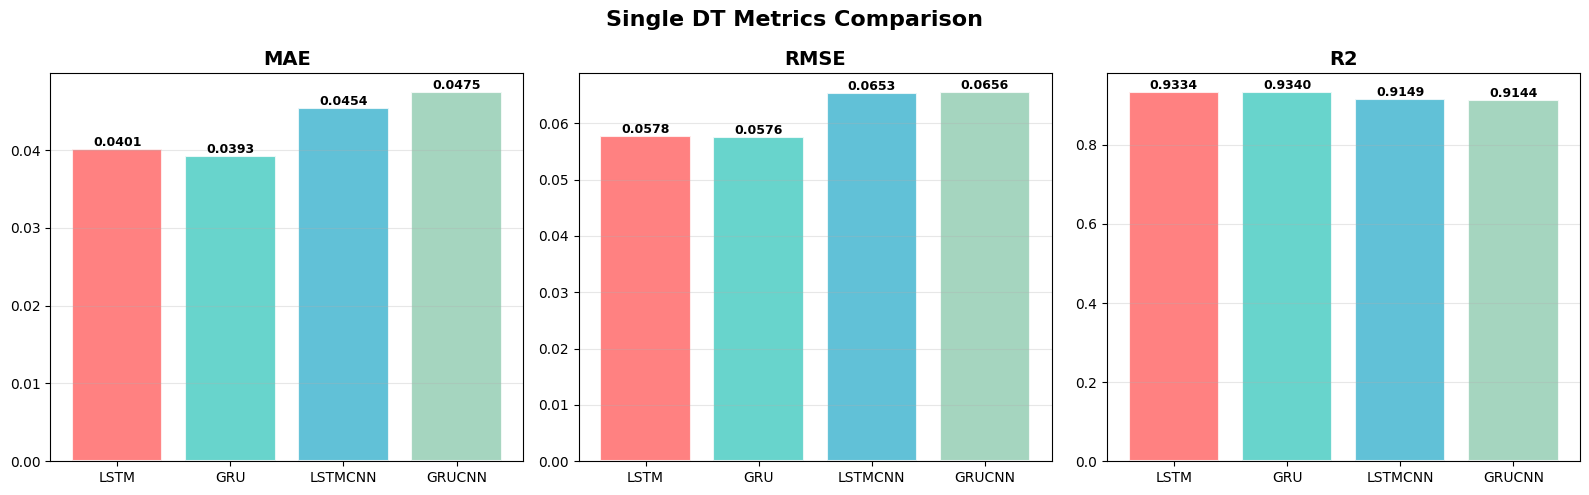

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Single DT Metrics Comparison', fontsize=16, fontweight='bold')
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    vals = [single_metrics[n][metric] for n in model_names]
    bars = ax.bar(model_names, vals, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('results/plots/single_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.3 Actual vs Predicted - 1-Day Forecast

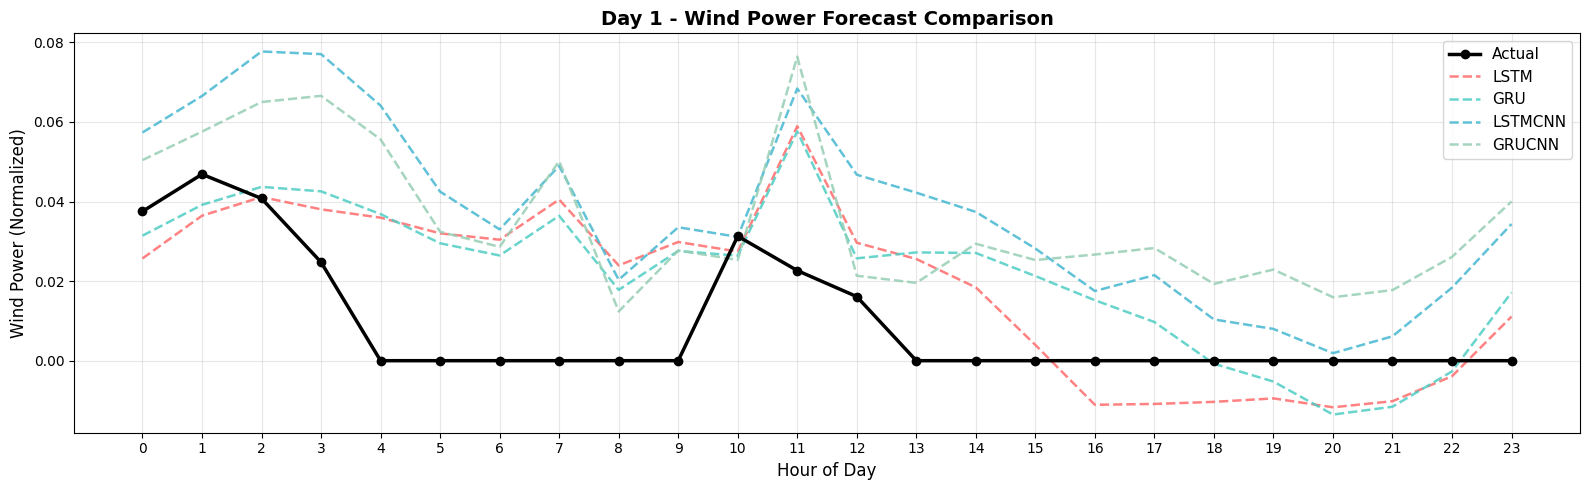

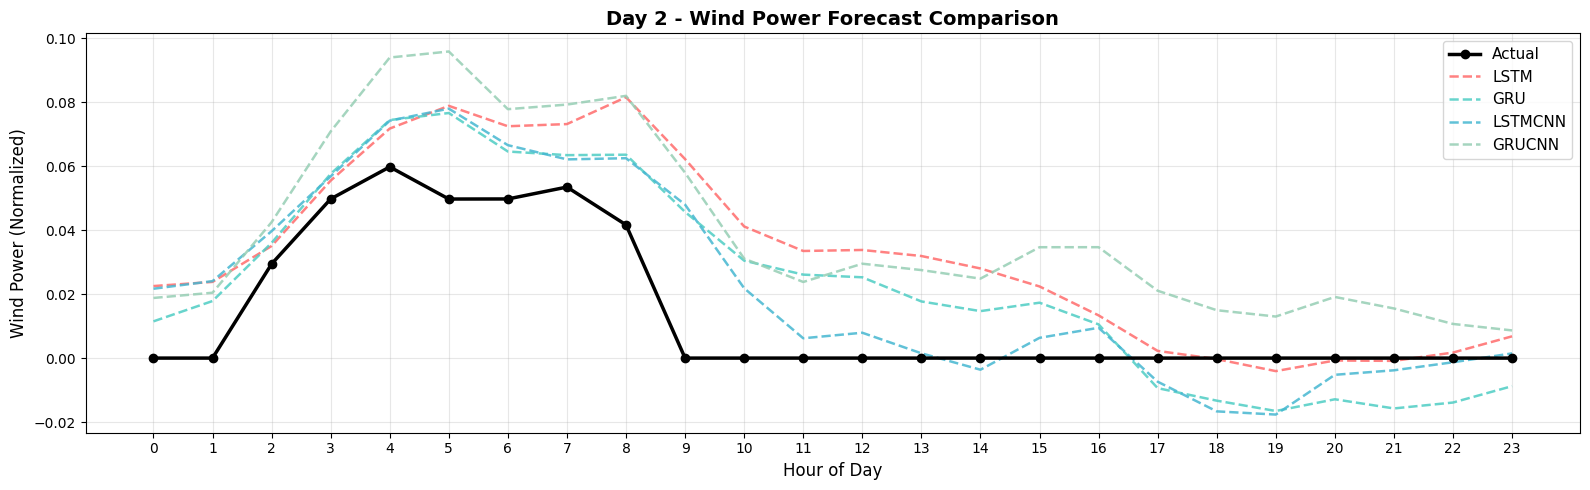

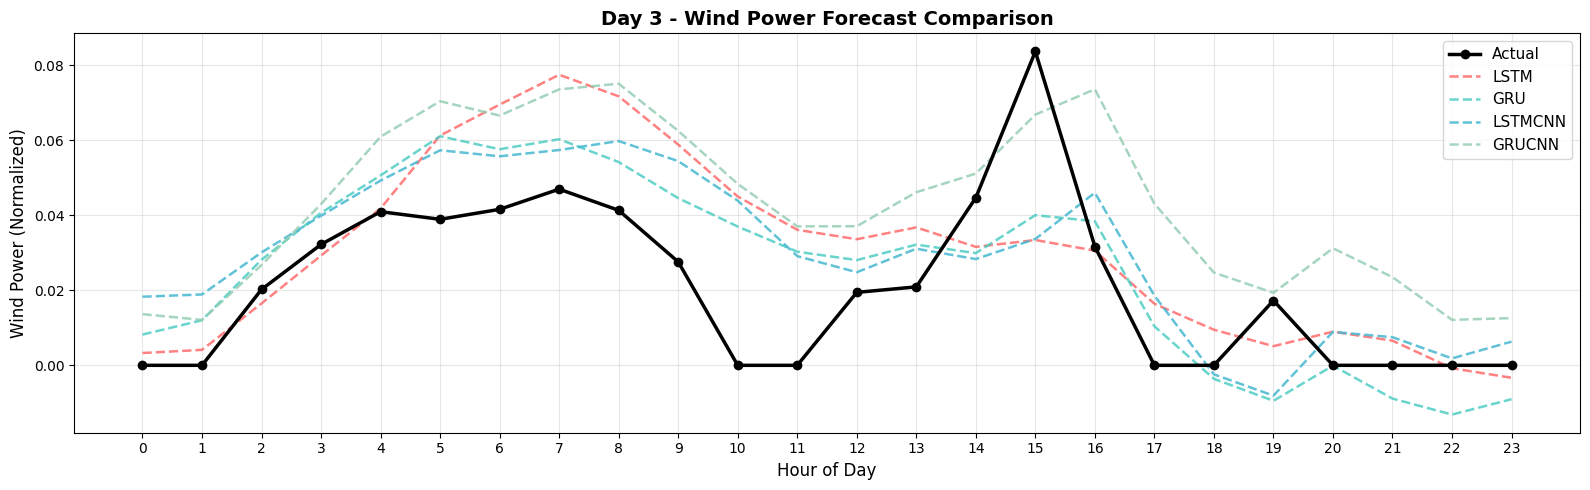

In [4]:
colors_map = {'LSTM': '#FF6B6B', 'GRU': '#4ECDC4', 'LSTMCNN': '#45B7D1', 'GRUCNN': '#96CEB4'}

for day_idx, start in enumerate([0, 48, 96]):
    fig, ax = plt.subplots(figsize=(16, 5))
    
    actual_kw = predictions['LSTM']['test_actual'][start:start+24]
    hours = np.arange(len(actual_kw))
    
    ax.plot(hours, actual_kw, 'ko-', linewidth=2.5, markersize=6, label='Actual', zorder=5)
    
    for name in model_names:
        pred_kw = predictions[name]['test_pred'][start:start+24]
        ax.plot(hours, pred_kw, '--', color=colors_map[name], linewidth=1.8, alpha=0.85, label=name)
    
    ax.set_xlabel('Hour of Day', fontsize=12)
    ax.set_ylabel('Wind Power (Normalized)', fontsize=12)
    ax.set_title(f'Day {day_idx+1} - Wind Power Forecast Comparison', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(hours)
    plt.tight_layout()
    plt.savefig(f'results/plots/day_{day_idx+1}_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()


## 3.4 Scatter Plots

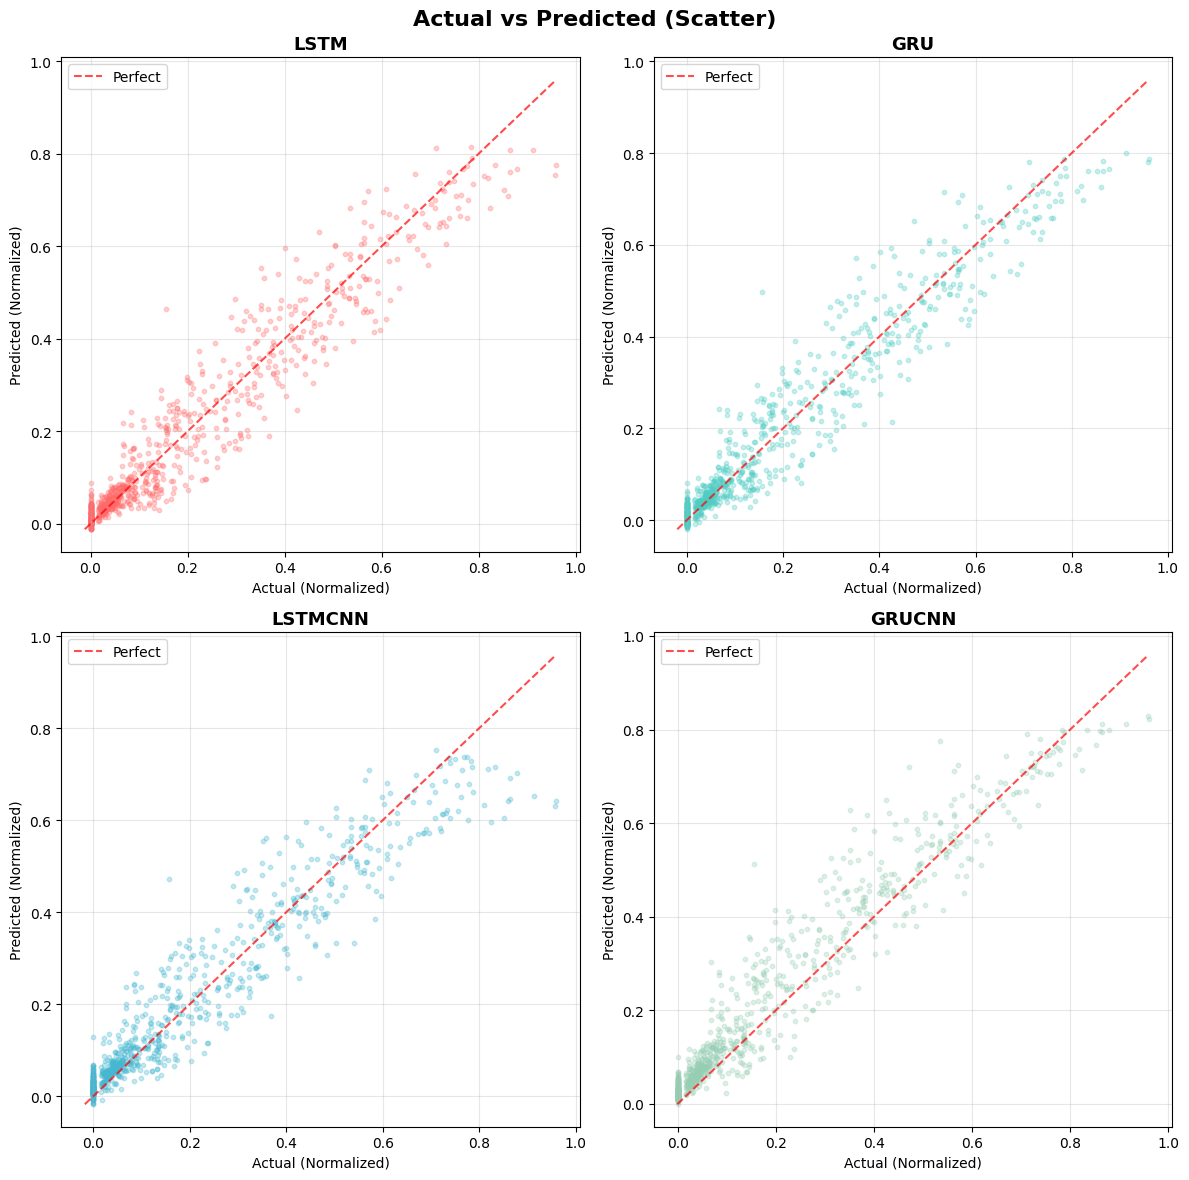

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Actual vs Predicted (Scatter)', fontsize=16, fontweight='bold')

for ax, name, c in zip(axes.flatten(), model_names, colors):
    actual = predictions[name]['test_actual']
    pred = predictions[name]['test_pred']
    
    ax.scatter(actual, pred, alpha=0.3, s=10, color=c)
    lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, alpha=0.7, label='Perfect')
    ax.set_xlabel('Actual (Normalized)')
    ax.set_ylabel('Predicted (Normalized)')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/plots/scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.5 Error Distribution

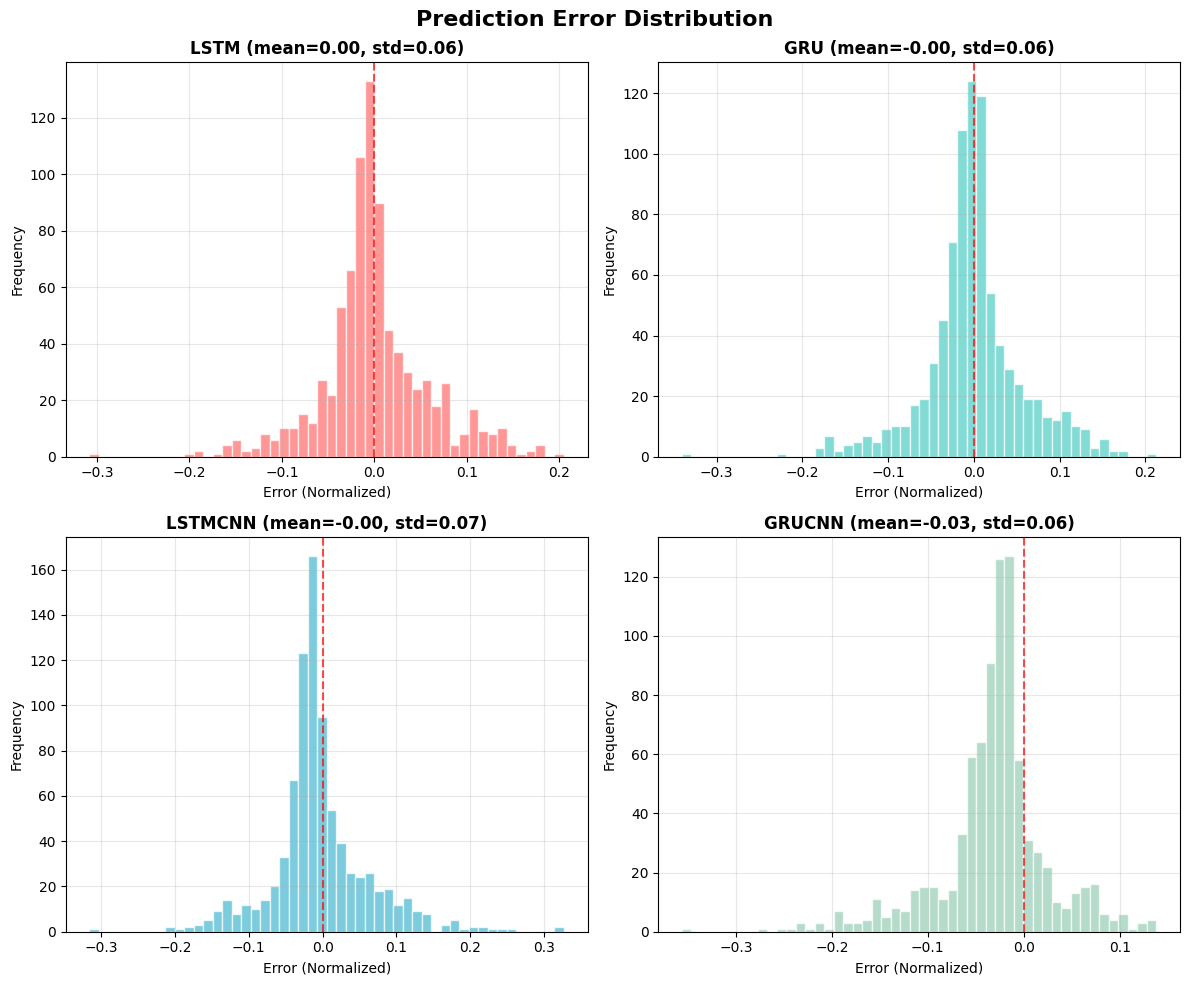

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Prediction Error Distribution', fontsize=16, fontweight='bold')

for ax, name, c in zip(axes.flatten(), model_names, colors):
    actual = predictions[name]['test_actual']
    pred = predictions[name]['test_pred']
    errors = actual - pred
    
    ax.hist(errors, bins=50, color=c, alpha=0.7, edgecolor='white')
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    ax.set_xlabel('Error (Normalized)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{name} (mean={errors.mean():.2f}, std={errors.std():.2f})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/plots/error_dist.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.6 Save Metrics

In [7]:
metrics_table.to_csv('results/single_dt_metrics.csv')
print("[OK] Saved: results/single_dt_metrics.csv")
print(metrics_table)


[OK] Saved: results/single_dt_metrics.csv
            MAE    RMSE    NMAE     MAPE      R2
Model                                           
LSTM     0.0401  0.0578  4.1752  10.3999  0.9334
GRU      0.0393  0.0576  4.0985   9.8579  0.9340
LSTMCNN  0.0454  0.0653  4.7308  12.4041  0.9149
GRUCNN   0.0475  0.0656  4.9494   7.8574  0.9144
